In [1]:
import pandas as pd

df = pd.read_csv("Student_Performance.csv")
df.head()


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [3]:
df.describe()
df.isnull().sum()


Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [4]:
df["Extracurricular Activities"] = df["Extracurricular Activities"].map({"Yes": 1, "No": 0})
df.head()


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


Performance Index                   1.000000
Previous Scores                     0.915189
Hours Studied                       0.373730
Sleep Hours                         0.048106
Sample Question Papers Practiced    0.043268
Extracurricular Activities          0.024525
Name: Performance Index, dtype: float64


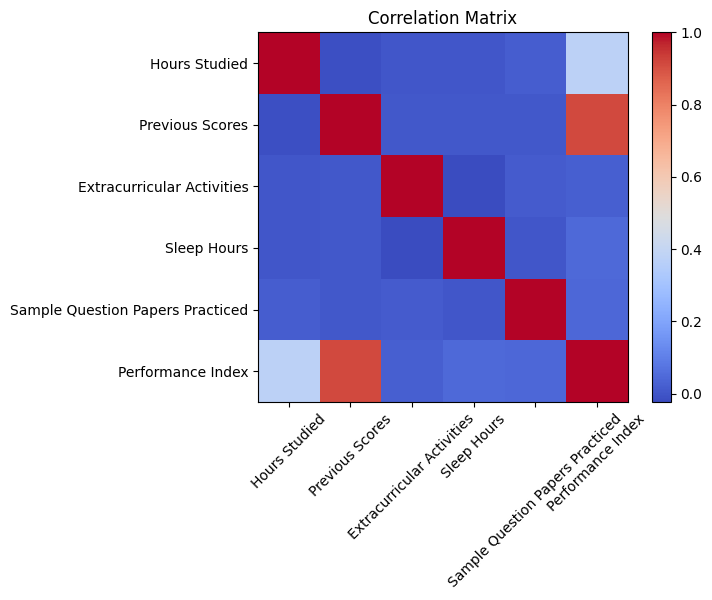

In [5]:
import matplotlib.pyplot as plt

corr = df.corr()
print(corr["Performance Index"].sort_values(ascending=False))

plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=45)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Correlation Matrix")
plt.show()


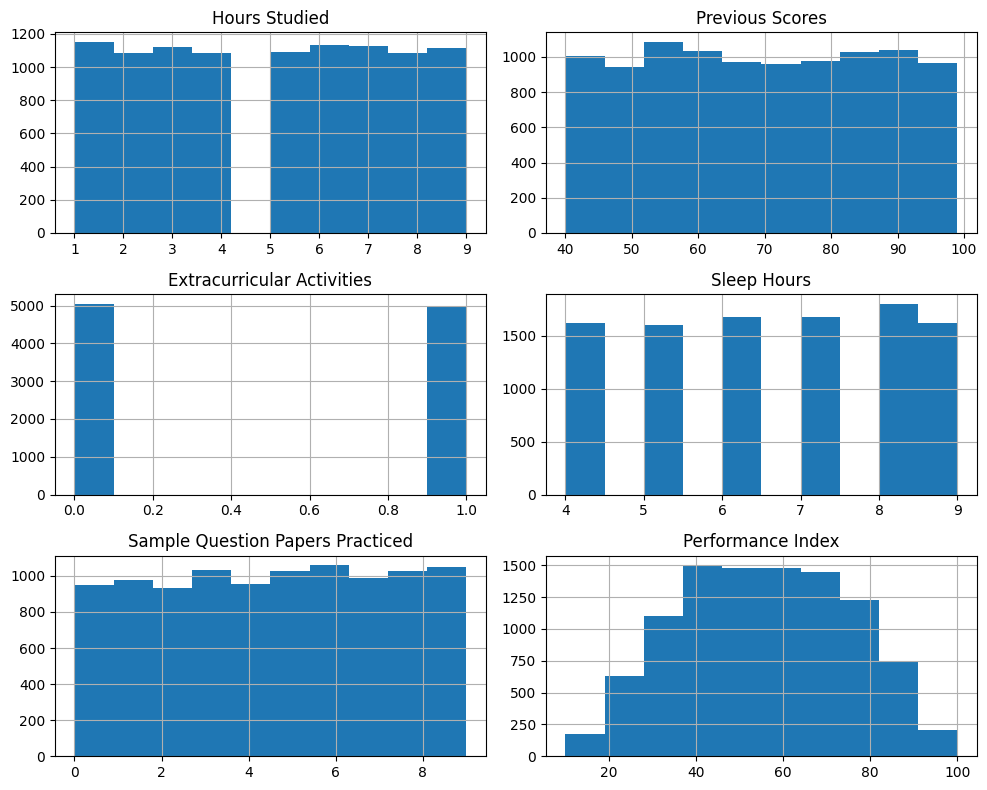

In [6]:
df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Ціль
y = df["Performance Index"]

# Фічі: усі крім target
X = df.drop("Performance Index", axis=1)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Масштабування
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Додаємо стовпчик одиниць для β0
X_train_final = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_final  = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

X_train_final.shape, X_test_final.shape


((8000, 6), (2000, 6))

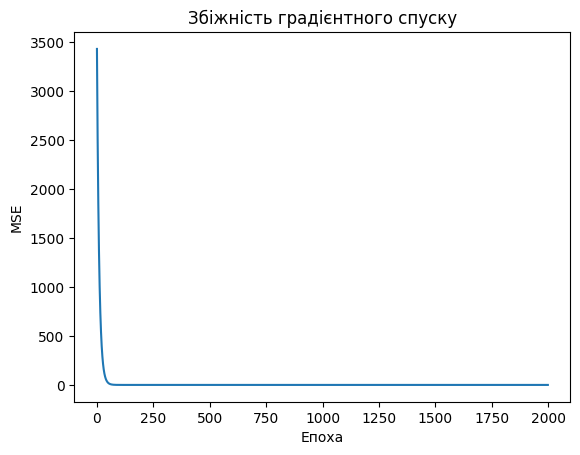

b_final: [55.3115      7.40134079 17.63727127  0.30429076  0.81003107  0.54884171]
MSE test: 4.082628398521852
R^2 test: 0.9889832909573145
MSE baseline (mean): 370.77303824999996


In [8]:
import numpy as np
import matplotlib.pyplot as plt

def predict(X, b):
    return X @ b

def mse(y_true, y_pred):
    y_true = np.asarray(y_true)
    return np.mean((y_pred - y_true) ** 2)

def gradient_descent(X, y, lr=0.05, epochs=2000):
    X = np.asarray(X)
    y = np.asarray(y)
    m, n = X.shape
    b = np.zeros(n)  # [b0, b1, ..., bn]
    cost_history = []

    for t in range(epochs):
        y_pred = X @ b
        error = y_pred - y
        grad = (X.T @ error) / m          # ∇MSE
        b = b - lr * grad                 # оновлення ваг
        cost = (error @ error) / m        # MSE
        cost_history.append(cost)

        # Захист від розбігання
        if t > 5 and (np.isnan(cost) or cost > 1e6):
            print(f"⚠️ дивергенція на епосі {t}, зменшуй lr")
            break

    return b, np.array(cost_history)

# Навчання
b_final, cost_history = gradient_descent(X_train_final, y_train.values, lr=0.05, epochs=2000)

# Крива збіжності
plt.plot(cost_history)
plt.xlabel("Епоха")
plt.ylabel("MSE")
plt.title("Збіжність градієнтного спуску")
plt.show()

# Оцінка на тесті
y_test_pred = predict(X_test_final, b_final)

def r2_np(y_true, y_pred):
    y_true = np.asarray(y_true)
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    return 1 - ss_res/ss_tot

mse_test = mse(y_test.values, y_test_pred)
r2_test = r2_np(y_test.values, y_test_pred)

# Бейзлайн: завжди прогнозувати середнє TRAIN-цілі
baseline = np.full_like(y_test.values, y_train.mean(), dtype=float)
mse_baseline = mse(y_test.values, baseline)

print("b_final:", b_final)
print("MSE test:", mse_test)
print("R^2 test:", r2_test)
print("MSE baseline (mean):", mse_baseline)


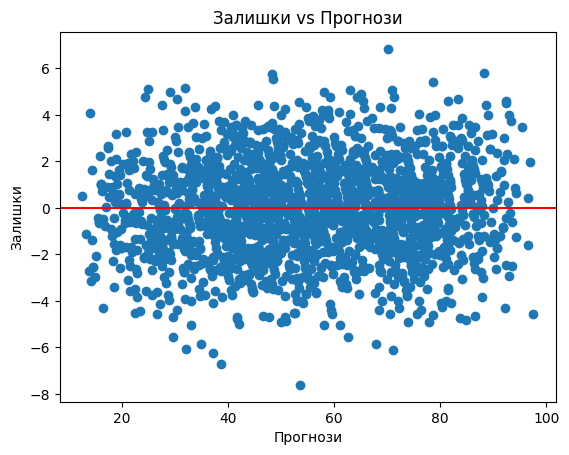

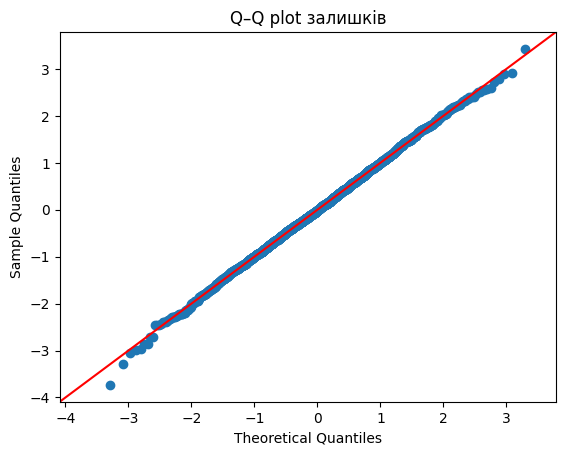

Durbin–Watson: 2.0471910397104827
VIF:
 [('Hours Studied', np.float64(1.0003869791709692)), ('Previous Scores', np.float64(1.0002433681390288)), ('Extracurricular Activities', np.float64(1.0004283022463154)), ('Sleep Hours', np.float64(1.0004613525942867)), ('Sample Question Papers Practiced', np.float64(1.0003204086793482))]


In [9]:
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Залишки
residuals = y_test.values - predict(X_test_final, b_final)

# 1. Лінійність: залишки vs прогнози
plt.scatter(predict(X_test_final, b_final), residuals)
plt.axhline(0, color='red')
plt.xlabel("Прогнози")
plt.ylabel("Залишки")
plt.title("Залишки vs Прогнози")
plt.show()

# 2. Нормальність залишків
sm.qqplot(residuals, line='45', fit=True)
plt.title("Q–Q plot залишків")
plt.show()

# 3. Durbin–Watson (автокореляція)
dw = durbin_watson(residuals)
print("Durbin–Watson:", dw)

# 4. VIF для мультиколінеарності
vif_data = []
for i in range(1, X_train_final.shape[1]):  # пропускаємо стовпець 1
    vif = variance_inflation_factor(X_train_final, i)
    vif_data.append((X.columns[i-1], vif))
print("VIF:\n", vif_data)
